# AI-Powered Student Risk & Employability Predictor

## GROUP 2

## Authors:
1. Andrew Nyakiba

2. Angela Wachira

3. Bobbin Bodo

4. Mercy Chepkoech

5. Ted Mwenda

### Instructor name: MARYANNE MWIKALI


### Project Type: Predictive Analytics - Supervised Machine Learning (Multiclass Classification)

### Datasets Used:


| Dataset | Source | Purpose |
|---|---|---|
| `data.csv` | UCI / Kaggle | Dropout prediction (primary, labelled) |
| `Academic_Risk_Prediction_DW.csv` | Kaggle | Supplementary academic features |
| `UECD_1200_dataset.csv` | Kaggle | Employability prediction |
| `Resume.csv` | Kaggle | NLP resume recommendations |

This notebook develops an AI-powered student success platform using academic and employability datasets. It utilizes machine learning classification to identify at-risk students and assess professional readiness to facilitate early institutional intervention and personalized career guidance.


## 1. Project Overview

Higher education plays a critical role in socio-economic mobility and personal development, making student success and workforce readiness essential priorities for educational institutions. This project focuses on predicting two key student outcomes: academic risk (dropout versus graduation) and employability readiness, using demographic, academic performance, and behavioral data collected from diverse student populations.

Through the application of advanced machine learning models, the study will identify the major factors influencing students’ educational trajectories and will estimate their likelihood of academic and career success. The insights that will be generated from this system can support institutions in implementing early intervention strategies for at-risk students and improving academic programs to better align with the evolving demands of the global workforce.

## 2. Business Understanding

### 2.1 Stakeholders

- University Administration: Focus on institutional retention and reputation.

- Academic Advisors: Utilize insights for early-warning student support.

- Students: Primary users for self-assessment and career planning.

- Career Services: To align student skills with industry demands.

- Employers: Interested in identifying job-ready candidates.


### 2.2 Business Problem

Institutions face high dropout rates and a significant gap between academic graduation and job market readiness. This project aims to predict academic failure and employability levels early to enable proactive institutional intervention and career guidance.

### 2.3 Objectives

- To build a classification model to predict student academic outcomes (Graduate, Dropout, Enrolled).

- To develop an employability assessment to categorize students into professional readiness levels.

- To identify the key demographic and academic features that drive student risk.

- To create a user-friendly interface for real-time prediction and decision-making.

### 2.4 Key Questions

1. What are the most significant predictors of student dropout?

2. How strongly do first-semester academic grades correlate with final graduation?

3. What impact do financial factors (scholarships and debt) have on student success?

4. Can we accurately predict a student's employability level based on their academic and technical skill profile?

###  Importation of Libraries

In [42]:
import warnings
warnings.filterwarnings('ignore')

# Core data
import csv
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ML — preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ML — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# ML — evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, classification_report)

# Clustering (NLP)
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Explainability
import shap

# Persistence
import joblib
import os

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [43]:
#Global configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})
PALETTE = ['#378ADD', '#D85A30', '#1D9E75', '#EF9F27', '#7F77DD', '#D4537E']

# File paths
PATH_DROPOUT   = '../data/data.csv'
PATH_ACADEMIC  = '../data/Academic Risk Prediction DW.csv'
PATH_EMPLOY    = '../data/UECD_1200_dataset.csv'
PATH_RESUME    = '../data/Resume text.csv.gz'

# Output directories
os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print("✓ Configuration set — random seed:", RANDOM_SEED)

✓ Configuration set — random seed: 42


## Global Configuration

---



Sets a fixed random seed (42) to ensure reproducible results across all models and splits.
Plot styling defaults (figure size, spine removal, colour palette) are defined once here and
inherited by all charts in the notebook. Dataset file paths are declared as named constants
so any file changes require edits in one place only. Finally, the `models/` and `outputs/`
directories are created upfront so all export cells run without errors on any machine.

In [44]:
# Download NLTK data (run once)
for pkg in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(pkg, quiet=True)
print("✓ NLTK resources ready")


✓ NLTK resources ready


## 3. DATA LOADING

---



We load each dataset separately 

> **Note:** `data.csv` uses semicolons as delimiters and `Resume.csv` has BOM + nested-CSV encoding — both require special handling documented below.


In [45]:
# Dropout dataset (data.csv)
# Semicolon-delimited; must pass sep=';'
df_dropout = pd.read_csv(PATH_DROPOUT, sep=';')

print(f"Shape : {df_dropout.shape}")
print(f"Target: {df_dropout['Target'].value_counts().to_dict()}")
df_dropout.head(3)


Shape : (4424, 37)
Target: {'Graduate': 2209, 'Dropout': 1421, 'Enrolled': 794}


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


In [46]:
# Academic risk warehouse
df_academic = pd.read_csv(PATH_ACADEMIC)

print(f"Shape  : {df_academic.shape}")
print(f"Sources: {df_academic['source'].value_counts().to_dict()}")
df_academic.head(3)


Shape  : (11523, 40)
Sources: {'StudentFactors': 6607, 'StudentPerf': 2392, 'StudentGrades': 1044, 'PerfScores': 1000, 'xAPI': 480}


,fact_id,source,gender,age,grade_letter,raisedhands,visited_resources,announcements_view,discussion,absence_days,...,exam_score,attendance,hours_studied,motivation_level,internet_access,tutoring_sessions,parental_involvement,family_income,previous_scores,sleep_hours
0,1,xAPI,male,11,D,15,16,2,20,under-7,...,67,80,20,medium,yes,1,medium,medium,67,7
1,2,xAPI,male,12,C,20,20,3,25,under-7,...,67,80,20,medium,yes,1,medium,medium,67,7
2,3,xAPI,male,11,D,10,7,0,30,above-7,...,67,80,20,medium,yes,1,medium,medium,67,7


In [47]:
# Employability dataset
df_employ = pd.read_csv(PATH_EMPLOY)

print(f"Shape: {df_employ.shape}")
print(f"Score present: {df_employ['Employment_Competitiveness_Score'].notna().sum()} / {len(df_employ)} rows")
df_employ.head(3)


Shape: (1200, 26)
Score present: 620 / 1200 rows


,GPA,Core_Subject_Score,Academic_Consistency,Research_Participation,Programming_Skill,Domain_Knowledge,Tool_Proficiency,Certification_Count,Internship_Count,Internship_Duration,...,Learning_Motivation,Career_Clarity,Market_Awareness,Higher_Study_Interest,Target_Industry_Code,Workshop_Participation,Online_Course_Hours,Networking_Activity,Learning_Path_Generation_Time,Employment_Competitiveness_Score
0,7.19,66.0,2.14,1.0,48.0,51.0,35.0,2.0,3.0,13.0,...,50.0,89.0,93.0,0.0,NaN,6.0,243.4,23.0,8.98,30.55
1,9.78,61.0,1.42,0.0,70.0,85.0,75.0,5.0,0.0,7.3,...,97.0,35.0,91.0,1.0,5.0,11.0,20.0,44.0,8.98,NaN
2,8.79,83.0,1.22,0.0,54.0,52.0,79.0,5.0,3.0,3.9,...,77.0,36.0,88.0,1.0,3.0,5.0,96.5,55.0,6.21,66.03


In [48]:
# Resume dataset (BOM + nested-CSV encoding + gzip compression)
def load_resume_csv(path):
    """Parse Resume.csv which wraps each row as a single quoted CSV cell and is gzip-compressed."""
    import gzip
    rows = []
    open_func = gzip.open if path.endswith('.gz') else open
    with open_func(path, 'rt', encoding='utf-8-sig') as f:
        for row in csv.reader(f):
            if row:
                rows.append(list(csv.reader([row[0]]))[0])
    header, data = rows[0], rows[1:]
    return pd.DataFrame(data, columns=header)

df_resume = load_resume_csv(PATH_RESUME)

print(f"Shape     : {df_resume.shape}")
print(f"Categories: {df_resume['category'].nunique()} unique")
df_resume.head(3)


Shape     : (2856, 5)
Categories: 65 unique


,resume_id,category,resume_text,skills_list,experience_years
0,1,HR,hr administrator marketing associate hr admini...,hr administrator marketing associate hr admini...,0.0
1,2,HR,hr specialist us hr operations summary versati...,hr specialist us hr operations summary versati...,0.0
2,3,HR,hr director summary over years experience in r...,hr director summary over years experience in r...,20.0


### 4. DATA EXPLORATION

#### 4.1  Dropout Dataset Exploration (df_dropout)

In [49]:

print("--- DROPOUT DATASET EXPLORATION ---")
print(f"Shape: {df_dropout.shape}")
print(f"\nColumns: {df_dropout.columns.tolist()}")
print(f"\nData Types:\n{df_dropout.dtypes}")
print("\nInfo:")
df_dropout.info()
print(f"\nMissing Values:\n{df_dropout.isna().sum()}")
print(f"\nDuplicates: {df_dropout.duplicated().sum()}")
print("\nDescriptive Statistics:")
display(df_dropout.describe(include='all'))


--- DROPOUT DATASET EXPLORATION ---
Shape: (4424, 37)

Columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Un

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


### Checking for Missing values in Dropout Dataset


MISSING VALUES HEATMAP - Dropout Dataset


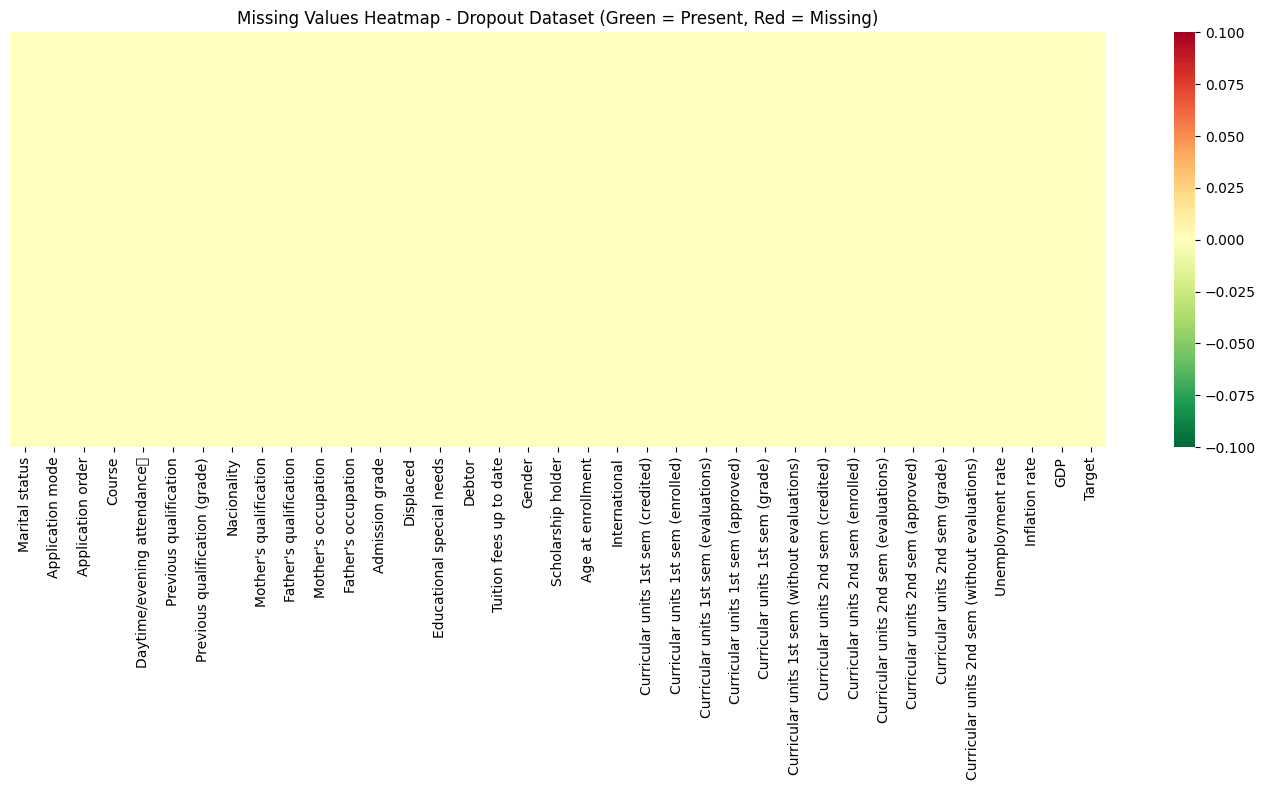


Total missing values: 0
Percentage of missing data: 0.00%

Missing values per column:
                                        Column  Missing_Count  Missing_Percentage
                                Marital status              0                 0.0
                              Application mode              0                 0.0
                             Application order              0                 0.0
                                        Course              0                 0.0
                  Daytime/evening attendance\t              0                 0.0
                        Previous qualification              0                 0.0
                Previous qualification (grade)              0                 0.0
                                   Nacionality              0                 0.0
                        Mother's qualification              0                 0.0
                        Father's qualification              0                 0.0
           

In [50]:
# Missing values visualization for 4.1
print("\n" + "="*70)
print("MISSING VALUES HEATMAP - Dropout Dataset")
print("="*70)

# Create missing values heatmap
missing_mask = df_dropout.isnull()
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(missing_mask, cbar=True, cmap='RdYlGn_r', ax=ax, yticklabels=False)
ax.set_title('Missing Values Heatmap - Dropout Dataset (Green = Present, Red = Missing)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/missing_values_heatmap_dropout.png', dpi=100, bbox_inches='tight')
plt.show()

# Summary table
print(f"\nTotal missing values: {missing_mask.sum().sum()}")
print(f"Percentage of missing data: {(missing_mask.sum().sum() / (df_dropout.shape[0] * df_dropout.shape[1]) * 100):.2f}%")
print("\nMissing values per column:")
missing_summary = pd.DataFrame({
    'Column': df_dropout.columns,
    'Missing_Count': df_dropout.isnull().sum(),
    'Missing_Percentage': (df_dropout.isnull().sum() / len(df_dropout) * 100).round(2)
})
print(missing_summary.to_string(index=False))


#### 4.2 Academic Risk Dataset Exploration (df_academic)

In [51]:
print("--- ACADEMIC RISK DATASET EXPLORATION ---")
print(f"Shape: {df_academic.shape}")
print(f"\nColumns: {df_academic.columns.tolist()}")
print(f"\nData Types:\n{df_academic.dtypes}")
print("\nInfo:")
df_academic.info()
print(f"\nMissing Values:\n{df_academic.isna().sum()}")
print(f"\nDuplicates: {df_academic.duplicated().sum()}")
print("\nDescriptive Statistics:")
display(df_academic.describe(include='all'))


--- ACADEMIC RISK DATASET EXPLORATION ---
Shape: (11523, 40)

Columns: ['fact_id', 'source', 'gender', 'age', 'grade_letter', 'raisedhands', 'visited_resources', 'announcements_view', 'discussion', 'absence_days', 'stage', 'topic', 'GPA', 'absences', 'study_time', 'parental_education', 'parental_support', 'tutoring', 'G1', 'G2', 'G3', 'failures', 'Medu', 'Fedu', 'math_score', 'science_score', 'english_score', 'avg_score', 'lunch', 'test_prep', 'exam_score', 'attendance', 'hours_studied', 'motivation_level', 'internet_access', 'tutoring_sessions', 'parental_involvement', 'family_income', 'previous_scores', 'sleep_hours']

Data Types:
fact_id                   int64
source                   object
gender                   object
age                       int64
grade_letter             object
raisedhands               int64
visited_resources         int64
announcements_view        int64
discussion                int64
absence_days             object
stage                    object
topic  

,fact_id,source,gender,age,grade_letter,raisedhands,visited_resources,announcements_view,discussion,absence_days,...,exam_score,attendance,hours_studied,motivation_level,internet_access,tutoring_sessions,parental_involvement,family_income,previous_scores,sleep_hours
count,11523.00000,11523,11523,11523.000000,11523,11523.000000,11523.000000,11523.000000,11523.000000,11523,...,11523.000000,11523.000000,11523.000000,11523,11523,11523.000000,11523,11523,11523.000000,11523.000000
unique,NaN,5,2,NaN,4,NaN,NaN,NaN,NaN,2,...,NaN,NaN,NaN,3,2,NaN,3,3,NaN,NaN
top,NaN,StudentFactors,male,NaN,C,NaN,NaN,NaN,NaN,under-7,...,NaN,NaN,NaN,medium,yes,NaN,medium,medium,NaN,NaN
freq,NaN,6607,6276,NaN,7980,NaN,NaN,NaN,NaN,11332,...,NaN,NaN,NaN,8267,11024,NaN,8278,7582,NaN,NaN
mean,5762.00000,NaN,NaN,16.024126,NaN,49.865660,64.575024,38.954960,39.178426,NaN,...,67.135121,79.987069,19.985854,NaN,NaN,1.283086,NaN,NaN,71.627441,7.016662
std,3326.54791,NaN,NaN,1.049102,NaN,6.308686,7.046119,5.430165,5.699782,NaN,...,2.948123,8.743649,4.536040,NaN,NaN,0.963245,NaN,NaN,11.611110,1.111740
min,1.00000,NaN,NaN,10.000000,NaN,0.000000,0.000000,0.000000,1.000000,NaN,...,55.000000,60.000000,1.000000,NaN,NaN,0.000000,NaN,NaN,50.000000,4.000000
25%,2881.50000,NaN,NaN,16.000000,NaN,50.000000,65.000000,39.000000,39.000000,NaN,...,66.000000,77.000000,19.000000,NaN,NaN,1.000000,NaN,NaN,67.000000,7.000000
50%,5762.00000,NaN,NaN,16.000000,NaN,50.000000,65.000000,39.000000,39.000000,NaN,...,67.000000,80.000000,20.000000,NaN,NaN,1.000000,NaN,NaN,67.000000,7.000000
75%,8642.50000,NaN,NaN,16.000000,NaN,50.000000,65.000000,39.000000,39.000000,NaN,...,68.000000,82.000000,21.000000,NaN,NaN,2.000000,NaN,NaN,78.000000,7.000000


### Checking for Missing Values in Academic Risk Dataset

Missing Values Summary:
fact_id                 0
source                  0
gender                  0
age                     0
grade_letter            0
raisedhands             0
visited_resources       0
announcements_view      0
discussion              0
absence_days            0
stage                   0
topic                   0
GPA                     0
absences                0
study_time              0
parental_education      0
parental_support        0
tutoring                0
G1                      0
G2                      0
G3                      0
failures                0
Medu                    0
Fedu                    0
math_score              0
science_score           0
english_score           0
avg_score               0
lunch                   0
test_prep               0
exam_score              0
attendance              0
hours_studied           0
motivation_level        0
internet_access         0
tutoring_sessions       0
parental_involvement    0
family_income 

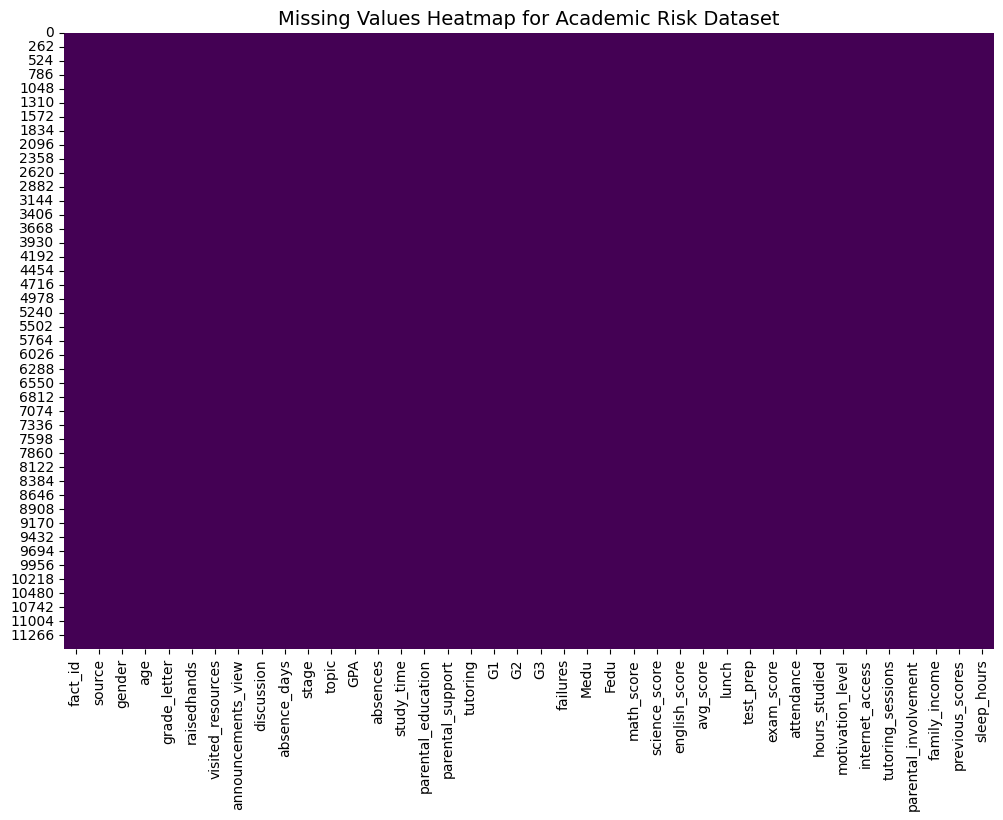

In [52]:
# Summary of missing values
print("Missing Values Summary:")
print(df_academic.isnull().sum())
print("\nPercentage of Missing Values:")
print((df_academic.isnull().sum() / len(df_academic)) * 100)

plt.figure(figsize=(12, 8))
sns.heatmap(df_academic.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap for Academic Risk Dataset')
plt.show()

#### 4.3 Employability Dataset Exploration (df_employ)

In [53]:
# 3. Individual Exploration: Employability Dataset
print("--- EMPLOYABILITY DATASET EXPLORATION ---")
print(f"Shape: {df_employ.shape}")
print(f"\nColumns: {df_employ.columns.tolist()}")
print(f"\nData Types:\n{df_employ.dtypes}")
print("\nInfo:")
df_employ.info()
print(f"\nMissing Values:\n{df_employ.isna().sum()}")
print(f"\nDuplicates: {df_employ.duplicated().sum()}")
print("\nDescriptive Statistics:")
display(df_employ.describe(include='all'))


--- EMPLOYABILITY DATASET EXPLORATION ---
Shape: (1200, 26)

Columns: ['GPA', 'Core_Subject_Score', 'Academic_Consistency', 'Research_Participation', 'Programming_Skill', 'Domain_Knowledge', 'Tool_Proficiency', 'Certification_Count', 'Internship_Count', 'Internship_Duration', 'Industry_Relevance', 'Project_Experience', 'Communication_Skill', 'Teamwork_Ability', 'Leadership_Potential', 'Adaptability', 'Learning_Motivation', 'Career_Clarity', 'Market_Awareness', 'Higher_Study_Interest', 'Target_Industry_Code', 'Workshop_Participation', 'Online_Course_Hours', 'Networking_Activity', 'Learning_Path_Generation_Time', 'Employment_Competitiveness_Score']

Data Types:
GPA                                 float64
Core_Subject_Score                  float64
Academic_Consistency                float64
Research_Participation              float64
Programming_Skill                   float64
Domain_Knowledge                    float64
Tool_Proficiency                    float64
Certification_Count     

,GPA,Core_Subject_Score,Academic_Consistency,Research_Participation,Programming_Skill,Domain_Knowledge,Tool_Proficiency,Certification_Count,Internship_Count,Internship_Duration,...,Learning_Motivation,Career_Clarity,Market_Awareness,Higher_Study_Interest,Target_Industry_Code,Workshop_Participation,Online_Course_Hours,Networking_Activity,Learning_Path_Generation_Time,Employment_Competitiveness_Score
count,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,...,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,1164.000000,620.000000
mean,7.750584,74.371134,1.494983,0.265464,68.997423,71.974227,64.268900,2.375430,2.064433,8.848969,...,73.768041,64.613402,66.878866,0.389175,4.122852,5.469072,124.414777,59.589347,6.245052,47.755145
std,1.319964,11.403099,0.576473,0.441770,17.299322,16.079051,20.023736,1.739466,1.403278,5.065535,...,14.324497,20.260344,19.053302,0.487773,1.984339,3.413328,73.549694,23.219609,3.324204,16.032071
min,5.520000,55.000000,0.500000,0.000000,40.000000,45.000000,30.000000,0.000000,0.000000,0.000000,...,50.000000,30.000000,35.000000,0.000000,1.000000,0.000000,0.200000,20.000000,0.520000,0.000000
25%,6.577500,65.000000,1.020000,0.000000,54.000000,58.000000,47.000000,1.000000,1.000000,4.600000,...,61.000000,47.000000,50.000000,0.000000,2.000000,3.000000,60.750000,40.000000,3.330000,36.067500
50%,7.800000,74.000000,1.500000,0.000000,68.000000,72.000000,63.000000,2.000000,2.000000,8.900000,...,73.000000,65.000000,68.000000,0.000000,4.000000,5.000000,124.400000,59.000000,6.220000,48.175000
75%,8.892500,84.000000,1.990000,1.000000,84.000000,86.000000,82.000000,4.000000,3.000000,13.100000,...,85.000000,83.000000,84.000000,1.000000,6.000000,8.000000,189.750000,80.000000,9.100000,58.482500
max,10.000000,94.000000,2.500000,1.000000,99.000000,99.000000,99.000000,5.000000,4.000000,18.000000,...,99.000000,99.000000,99.000000,1.000000,7.000000,11.000000,249.700000,99.000000,12.000000,100.000000


### Checking for Missing Values in Employability Dataset

Employability Dataset Missing Values Summary:
                                  missing_count  missing_pct
Employment_Competitiveness_Score            580    48.333333
Core_Subject_Score                           36     3.000000
Learning_Path_Generation_Time                36     3.000000
Networking_Activity                          36     3.000000
Online_Course_Hours                          36     3.000000
Workshop_Participation                       36     3.000000
Target_Industry_Code                         36     3.000000
Higher_Study_Interest                        36     3.000000
Market_Awareness                             36     3.000000
Career_Clarity                               36     3.000000
Learning_Motivation                          36     3.000000
Adaptability                                 36     3.000000
Leadership_Potential                         36     3.000000
GPA                                          36     3.000000
Communication_Skill                    

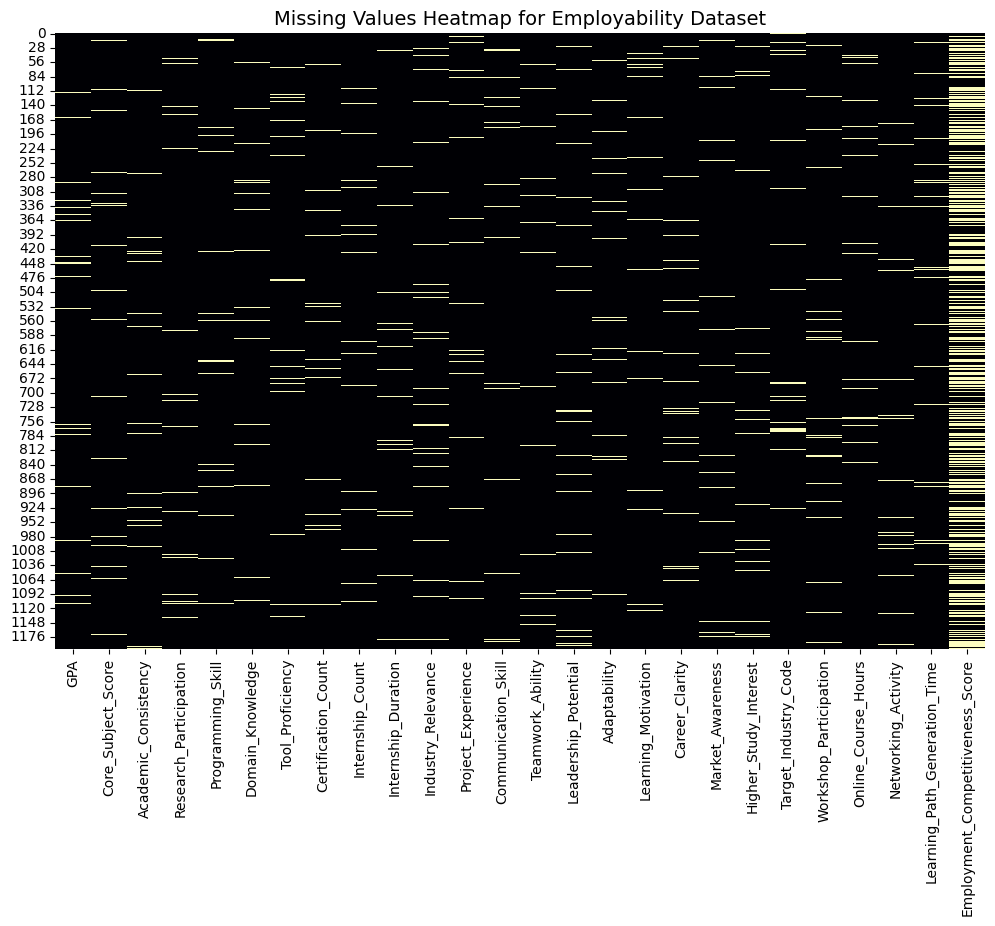

In [54]:
# Employability dataset missing values summary and visualization
missing_counts = df_employ.isnull().sum()
missing_pct = (missing_counts / len(df_employ)) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print("Employability Dataset Missing Values Summary:")
print(missing_summary)

plt.figure(figsize=(12, 8))
sns.heatmap(df_employ.isnull(), cbar=False, cmap='magma')
plt.title('Missing Values Heatmap for Employability Dataset')
plt.show()

#### 4.4  Resume Dataset Exploration (df_resume)

In [55]:
print("--- RESUME DATASET EXPLORATION ---")
print(f"Shape: {df_resume.shape}")
print(f"\nColumns: {df_resume.columns.tolist()}")
print(f"\nData Types:\n{df_resume.dtypes}")
print("\nInfo:")
df_resume.info()
print(f"\nMissing Values:\n{df_resume.isna().sum()}")
print(f"\nDuplicates: {df_resume.duplicated().sum()}")
print("\nDescriptive Statistics:")
display(df_resume.describe(include='all'))


--- RESUME DATASET EXPLORATION ---
Shape: (2856, 5)

Columns: ['resume_id', 'category', 'resume_text', 'skills_list', 'experience_years']

Data Types:
resume_id           object
category            object
resume_text         object
skills_list         object
experience_years    object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2856 entries, 0 to 2855
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   resume_id         2856 non-null   object
 1   category          2856 non-null   object
 2   resume_text       2836 non-null   object
 3   skills_list       2834 non-null   object
 4   experience_years  2818 non-null   object
dtypes: object(5)
memory usage: 111.7+ KB

Missing Values:
resume_id            0
category             0
resume_text         20
skills_list         22
experience_years    38
dtype: int64

Duplicates: 0

Descriptive Statistics:


,resume_id,category,resume_text,skills_list,experience_years
count,2856,2856,2836,2834,2818
unique,2856,65,2835,2833,75
top,1,HR,experienced data scientist with a strong backg...,experienced data scientist with a strong backg...,0.0
freq,1,120,2,2,1884


### Checking for Missing Values in Resume Dataset

Resume Dataset Missing Values Summary:
                  missing_count  missing_pct
experience_years             38     1.330532
skills_list                  22     0.770308
resume_text                  20     0.700280
resume_id                     0     0.000000
category                      0     0.000000


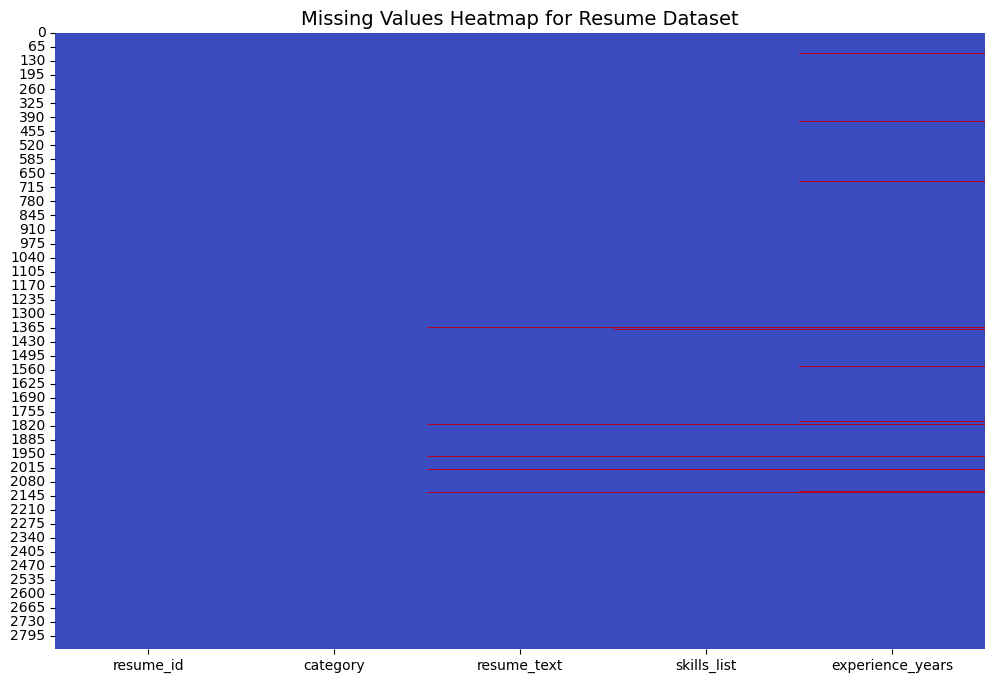

In [56]:
# Resume dataset missing values summary and visualization
resume_missing_counts = df_resume.isnull().sum()
resume_missing_pct = (resume_missing_counts / len(df_resume)) * 100
resume_missing_summary = pd.DataFrame({
    'missing_count': resume_missing_counts,
    'missing_pct': resume_missing_pct
}).sort_values('missing_count', ascending=False)

print("Resume Dataset Missing Values Summary:")
print(resume_missing_summary)

plt.figure(figsize=(12, 8))
sns.heatmap(df_resume.isnull(), cbar=False, cmap='coolwarm')
plt.title('Missing Values Heatmap for Resume Dataset')
plt.show()

## 5. DATA CLEANING

#### 5.1 Cleaning the Dropout Dataset (df_dropout)
This focuses on fixing the column name with the trailing tab and standardizing the names for easier access.

In [57]:
# 1. Cleaning: Dropout Dataset
print("Cleaning Dropout Dataset...")

# Remove trailing whitespace/tabs from column names and standardize to lowercase
df_dropout.columns = df_dropout.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')


print(f"Cleaned Columns: {df_dropout.columns.tolist()[:5]}...")
print("✅ Column names standardized.")


Cleaning Dropout Dataset...
Cleaned Columns: ['marital_status', 'application_mode', 'application_order', 'course', 'daytime/evening_attendance']...
✅ Column names standardized.


In [58]:
# Replacing nacionality with nationality
df_dropout = df_dropout.rename(columns={'nacionality': 'nationality'})


In [59]:
df_dropout.head()

,marital_status,application_mode,application_order,course,daytime/evening_attendance,previous_qualification,previous_qualification_grade,nationality,mother's_qualification,father's_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [60]:
df_dropout.isna().sum()

marital_status                                  0
application_mode                                0
application_order                               0
course                                          0
daytime/evening_attendance                      0
previous_qualification                          0
previous_qualification_grade                    0
nationality                                     0
mother's_qualification                          0
father's_qualification                          0
mother's_occupation                             0
father's_occupation                             0
admission_grade                                 0
displaced                                       0
educational_special_needs                       0
debtor                                          0
tuition_fees_up_to_date                         0
gender                                          0
scholarship_holder                              0
age_at_enrollment                               0


#### 5.2 Cleaning the Academic Risk Dataset (df_academic)

Standardizing column names and ensuring consistency.

In [61]:
# 2. Cleaning: Academic Risk Dataset
print("\nCleaning Academic Risk Dataset...")

# Standardize column names
df_academic.columns = df_academic.columns.str.strip().str.lower().str.replace(' ', '_')

# Safety check for duplicates (though exploration showed 0)
df_academic = df_academic.drop_duplicates()

print(f"New Shape: {df_academic.shape}")
print("✅ Academic dataset cleaned.")



Cleaning Academic Risk Dataset...
New Shape: (11523, 40)
✅ Academic dataset cleaned.


In [62]:
df_academic.head()

,fact_id,source,gender,age,grade_letter,raisedhands,visited_resources,announcements_view,discussion,absence_days,...,exam_score,attendance,hours_studied,motivation_level,internet_access,tutoring_sessions,parental_involvement,family_income,previous_scores,sleep_hours
0,1,xAPI,male,11,D,15,16,2,20,under-7,...,67,80,20,medium,yes,1,medium,medium,67,7
1,2,xAPI,male,12,C,20,20,3,25,under-7,...,67,80,20,medium,yes,1,medium,medium,67,7
2,3,xAPI,male,11,D,10,7,0,30,above-7,...,67,80,20,medium,yes,1,medium,medium,67,7
3,4,xAPI,male,11,C,30,25,5,35,above-7,...,67,80,20,medium,yes,1,medium,medium,67,7
4,5,xAPI,male,11,B,40,50,12,50,above-7,...,67,80,20,medium,yes,1,medium,medium,67,7


In [63]:
df_academic.isna().sum()

fact_id                 0
source                  0
gender                  0
age                     0
grade_letter            0
raisedhands             0
visited_resources       0
announcements_view      0
discussion              0
absence_days            0
stage                   0
topic                   0
gpa                     0
absences                0
study_time              0
parental_education      0
parental_support        0
tutoring                0
g1                      0
g2                      0
g3                      0
failures                0
medu                    0
fedu                    0
math_score              0
science_score           0
english_score           0
avg_score               0
lunch                   0
test_prep               0
exam_score              0
attendance              0
hours_studied           0
motivation_level        0
internet_access         0
tutoring_sessions       0
parental_involvement    0
family_income           0
previous_sco

#### 5.3 Cleaning the Employability Dataset (df_employ)

Handling missing values in the target and specific features.

In [64]:
# Drop the 36 fully-null rows
df_employ = df_employ.dropna(how='all')

# Drop rows where the target score is missing since we can't predict without it
df_employ = df_employ.dropna(subset=['Employment_Competitiveness_Score'])

# Standardize the column names (lowercase and underscores)
df_employ.columns = [c.strip().lower().replace(' ', '_') for c in df_employ.columns]

# Safety check: Fill missing industry codes with the mode (most common)
if 'target_industry_code' in df_employ.columns:
    industry_mode = df_employ['target_industry_code'].mode()[0]
    df_employ['target_industry_code'] = df_employ['target_industry_code'].fillna(industry_mode)

print(f"✅ Employability dataset cleaned. Rows remaining: {len(df_employ)}")


✅ Employability dataset cleaned. Rows remaining: 620


In [65]:
df_employ.head()

,gpa,core_subject_score,academic_consistency,research_participation,programming_skill,domain_knowledge,tool_proficiency,certification_count,internship_count,internship_duration,...,learning_motivation,career_clarity,market_awareness,higher_study_interest,target_industry_code,workshop_participation,online_course_hours,networking_activity,learning_path_generation_time,employment_competitiveness_score
0,7.19,66.0,2.14,1.0,48.0,51.0,35.0,2.0,3.0,13.0,...,50.0,89.0,93.0,0.0,7.0,6.0,243.4,23.0,8.98,30.55
2,8.79,83.0,1.22,0.0,54.0,52.0,79.0,5.0,3.0,3.9,...,77.0,36.0,88.0,1.0,3.0,5.0,96.5,55.0,6.21,66.03
4,6.20,87.0,2.16,0.0,79.0,95.0,47.0,3.0,2.0,5.1,...,73.0,86.0,86.0,0.0,3.0,3.0,220.0,63.0,7.17,47.25
8,8.21,65.0,2.15,0.0,65.0,82.0,91.0,2.0,2.0,8.2,...,56.0,33.0,95.0,1.0,6.0,6.0,117.8,54.0,4.57,43.92
10,5.59,80.0,0.98,0.0,56.0,49.0,87.0,0.0,0.0,17.7,...,81.0,54.0,55.0,1.0,2.0,4.0,218.5,37.0,4.92,26.42


In [66]:
# Handle the 18 missing values in Research Participation


if 'research_participation' in df_employ.columns:
    participation_mode = df_employ['research_participation'].mode()[0]
    df_employ['research_participation'] = df_employ['research_participation'].fillna(participation_mode)
    
print(f"✅ Research Participation fixed. Nulls remaining: {df_employ['research_participation'].isna().sum()}")


✅ Research Participation fixed. Nulls remaining: 0


In [67]:
df_employ.isna().sum()

gpa                                  0
core_subject_score                   0
academic_consistency                 0
research_participation               0
programming_skill                    0
domain_knowledge                     0
tool_proficiency                     0
certification_count                  0
internship_count                     0
internship_duration                  0
industry_relevance                   0
project_experience                   0
communication_skill                  0
teamwork_ability                     0
leadership_potential                 0
adaptability                         0
learning_motivation                  0
career_clarity                       0
market_awareness                     0
higher_study_interest               18
target_industry_code                 0
workshop_participation               0
online_course_hours                  0
networking_activity                  0
learning_path_generation_time        0
employment_competitivenes

### 5.4 Cleaning the Resume Dataset (df_resume)

Handling missing text and basic preprocessing for NLP.

In [68]:
# 1. Drop the 20 rows with missing resume_text rows with no text cannot be used in the NLP pipeline
df_resume = df_resume.dropna(subset=['resume_text'])

# 2. Fix the experience_years column
# Convert to a binary flag 'has_experience' (1 if > 0, else 0)

def calculate_experience_flag(val):
    try:
        val = float(val)
        # If it's a crazy year like 2015, or NaN, or 0, we treat it as 0
        if val > 100 or val <= 0 or pd.isna(val):
            return 0
        return 1
    except:
        return 0

df_resume['has_experience'] = df_resume['experience_years'].apply(calculate_experience_flag)

# 3. Standardize column names
df_resume.columns = [c.strip().lower().replace(' ', '_') for c in df_resume.columns]

# 4. Optional: Fill skills_list nulls with an empty string just to be safe
df_resume['skills_list'] = df_resume['skills_list'].fillna('not_specified')

print(f"✅ Resume dataset cleaned.")
print(f"Final Shape: {df_resume.shape}")
print(f"Experience flag breakdown:\n{df_resume['has_experience'].value_counts()}")


✅ Resume dataset cleaned.
Final Shape: (2836, 6)
Experience flag breakdown:
has_experience
0    1940
1     896
Name: count, dtype: int64
